In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.datasets import load_gbsg2


df = load_gbsg2()

df.head()

,horTh,age,menostat,tsize,tgrade,pnodes,progrec,estrec,time,cens
0,no,70,Post,21,II,3,48,66,1814,1
1,yes,56,Post,12,II,7,61,77,2018,1
2,yes,58,Post,35,II,9,52,271,712,1
3,yes,59,Post,17,II,4,60,29,1807,1
4,no,73,Post,35,II,1,26,65,772,1


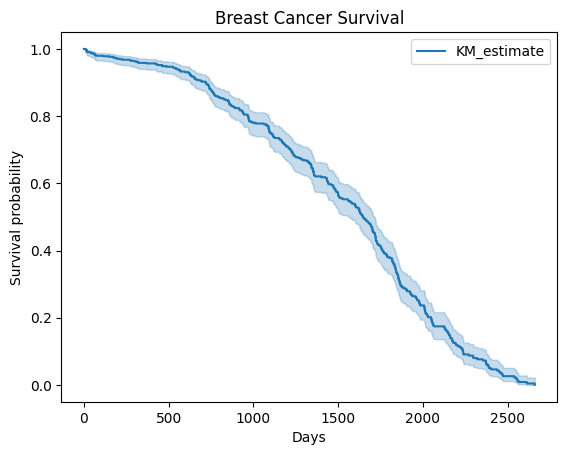

In [20]:
df["event"] = 1 - df["cens"]

kmf = KaplanMeierFitter()

kmf.fit(
    durations=df["time"],
    event_observed=df["event"]
)

kmf.plot_survival_function()

plt.title("Breast Cancer Survival")
plt.xlabel("Days")
plt.ylabel("Survival probability")

plt.show()

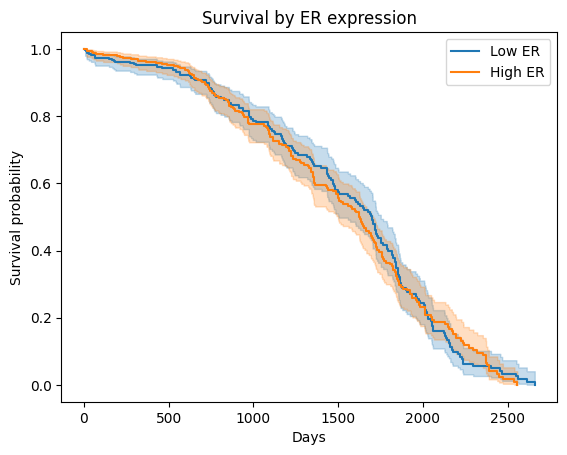

In [22]:
median_er = df["estrec"].median()

df["estrec_group"] = df["estrec"] > median_er
kmf = KaplanMeierFitter()

low = df[df["estrec_group"] == False]
high = df[df["estrec_group"] == True]

ax = plt.subplot(111)

kmf.fit(low["time"], low["event"], label="Low ER")
kmf.plot(ax=ax)

kmf.fit(high["time"], high["event"], label="High ER")
kmf.plot(ax=ax)

plt.title("Survival by ER expression")
plt.xlabel("Days")
plt.ylabel("Survival probability")

plt.show()

In [23]:
from lifelines.statistics import logrank_test

results = logrank_test(
    low["time"],
    high["time"],
    event_observed_A=low["event"],
    event_observed_B=high["event"]
)

results

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           0.08 0.78      0.36

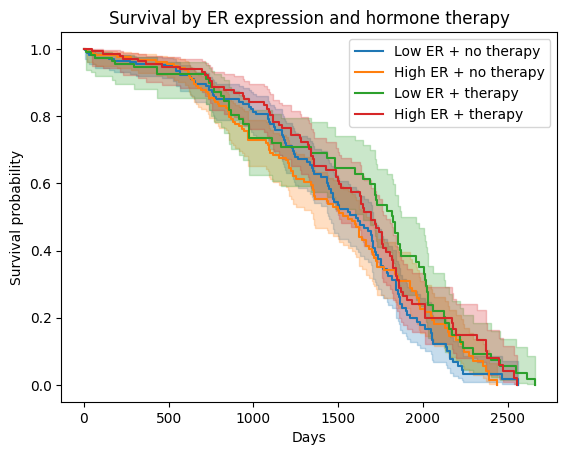

In [33]:
median_er = df["estrec"].median()
df["er_group"] = df["estrec"] > median_er
g1 = df[(df["er_group"] == False) & (df["horTh"] == "no")].copy()
g2 = df[(df["er_group"] == True)  & (df["horTh"] == "no")].copy()
g3 = df[(df["er_group"] == False) & (df["horTh"] == "yes")].copy()
g4 = df[(df["er_group"] == True)  & (df["horTh"] == "yes")].copy()

from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()
ax = plt.subplot(111)

kmf.fit(g1["time"], g1["event"], label="Low ER + no therapy")
kmf.plot(ax=ax)

kmf.fit(g2["time"], g2["event"], label="High ER + no therapy")
kmf.plot(ax=ax)

kmf.fit(g3["time"], g3["event"], label="Low ER + therapy")
kmf.plot(ax=ax)

kmf.fit(g4["time"], g4["event"], label="High ER + therapy")
kmf.plot(ax=ax)

plt.title("Survival by ER expression and hormone therapy")
plt.xlabel("Days")
plt.ylabel("Survival probability")
plt.show()

In [34]:
from lifelines.statistics import multivariate_logrank_test

df["group"] = (
    df["er_group"].astype(str) + "_" + df["horTh"]
)

results = multivariate_logrank_test(
    df["time"],
    df["group"],
    df["event"]
)

results.print_summary()

In [36]:
from lifelines import CoxPHFitter
df["horTh_binary"] = (df["horTh"] == "yes").astype(int)
cox_df = df[[
    "time",
    "event",
    "age",
    "pnodes",
    "tsize",
    "estrec",
    "horTh_binary"
]].copy()
cph = CoxPHFitter()

cph.fit(
    cox_df,
    duration_col="time",
    event_col="event"
)
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 686 total observations, 299 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 686
number of events observed = 387
   partial log-likelihood = -2005.77
         time fit was run = 2026-03-09 14:58:56 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
age          -0.01      0.99      0.01           -0.02            0.01                0.98                1.01
pnodes        0.02      1.02      0.01           -0.01            0.04                0.99                1.04
tsize         0.00      1.00      0.00           -0.01            0.01                0.99                1.01
estrec        0.00      1.00      0.00           -0.00            0.00                1.00                1.00
horTh_binary -0.24      0.79      0.11           -0.45           -0.03                0.64                0.97

              cmp to     z    p  -log2(p)
covariate                                
age             0.00 -0.98 0.33      1.60
pnodes          0.00  1.41 0.16      2.66
tsize           0.00  0.52 0.61      0.72
estrec          0.00  0.90 0.37      1.45
horTh_binary    0.00 -2.25 0.02      5.35
---
Concordance = 0.53
Partial AIC = 4021.55
log-likelihood ratio test = 9.71 on 5 df
-log2(p) of ll-ratio test = 3.57

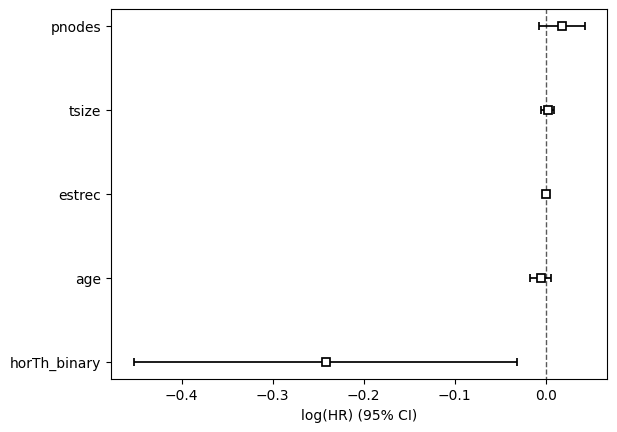

In [37]:
cph.plot()
plt.show()

In [38]:
df["ER_therapy_interaction"] = df["estrec"] * df["horTh_binary"]
cox_df = df[[
    "time",
    "event",
    "age",
    "pnodes",
    "tsize",
    "estrec",
    "horTh_binary",
    "ER_therapy_interaction"
]].copy()

cph = CoxPHFitter()
cph.fit(cox_df, duration_col="time", event_col="event")

cph.print_summary()

<lifelines.CoxPHFitter: fitted with 686 total observations, 299 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 686
number of events observed = 387
   partial log-likelihood = -2003.44
         time fit was run = 2026-03-09 15:02:54 UTC

---
                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                               
age                    -0.00      1.00      0.01           -0.02            0.01                0.98                1.01
pnodes                  0.02      1.02      0.01           -0.01            0.04                0.99                1.04
tsize                   0.00      1.00      0.00           -0.01            0.01                0.99                1.01
estrec                 -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
horTh_binary           -0.41      0.66      0.13           -0.68           -0.15                0.51                0.86
ER_therapy_interaction  0.00      1.00      0.00            0.00            0.00                1.00                1.00

                        cmp to     z      p  -log2(p)
covariate                                            
age                       0.00 -0.80   0.43      1.23
pnodes                    0.00  1.27   0.20      2.30
tsize                     0.00  0.53   0.59      0.75
estrec                    0.00 -0.89   0.37      1.42
horTh_binary              0.00 -3.08 <0.005      8.90
ER_therapy_interaction    0.00  2.15   0.03      5.00
---
Concordance = 0.55
Partial AIC = 4018.88
log-likelihood ratio test = 14.38 on 6 df
-log2(p) of ll-ratio test = 5.28

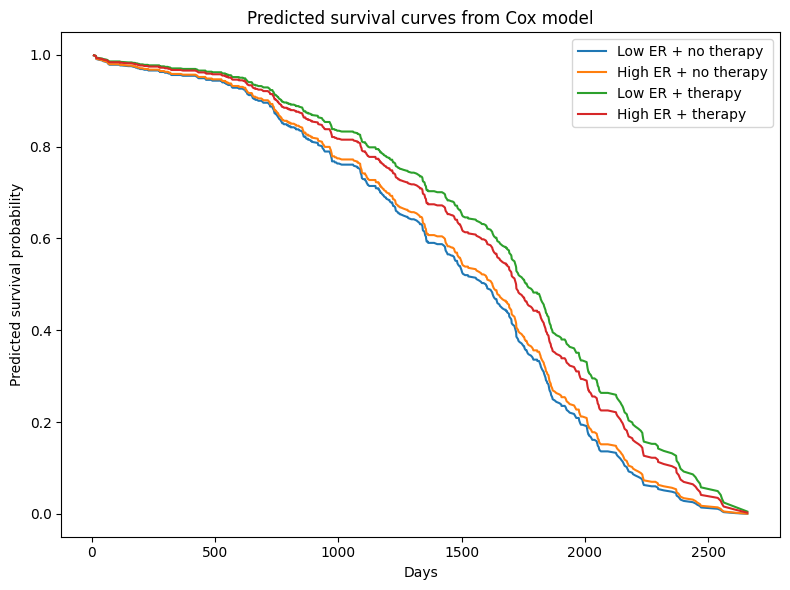

In [42]:
age_med = df["age"].median()
pnodes_med = df["pnodes"].median()
tsize_med = df["tsize"].median()

er_low = df["estrec"].quantile(0.25)
er_high = df["estrec"].quantile(0.75)

age_med, pnodes_med, tsize_med, er_low, er_high
profiles = pd.DataFrame({
    "age": [age_med, age_med, age_med, age_med],
    "pnodes": [pnodes_med, pnodes_med, pnodes_med, pnodes_med],
    "tsize": [tsize_med, tsize_med, tsize_med, tsize_med],
    "estrec": [er_low, er_high, er_low, er_high],
    "horTh_binary": [0, 0, 1, 1]
})
profiles["ER_therapy_interaction"] = (
    profiles["estrec"] * profiles["horTh_binary"]
)
labels = [
    "Low ER + no therapy",
    "High ER + no therapy",
    "Low ER + therapy",
    "High ER + therapy"
]
surv_funcs = cph.predict_survival_function(profiles)
plt.figure(figsize=(8,6))

for i, label in enumerate(labels):
    plt.plot(surv_funcs.index, surv_funcs.iloc[:, i], label=label)

plt.title("Predicted survival curves from Cox model")
plt.xlabel("Days")
plt.ylabel("Predicted survival probability")
plt.legend()
plt.tight_layout()
plt.savefig("predicted_survival_curves_cox.png", dpi=300)
plt.show()




In [45]:
from lifelines import CoxPHFitter

df["horTh_binary"] = (df["horTh"] == "yes").astype(int)
df["ER_therapy_interaction"] = df["estrec"] * df["horTh_binary"]

cox_df = df[[
    "time",
    "event",
    "age",
    "pnodes",
    "tsize",
    "estrec",
    "horTh_binary",
    "ER_therapy_interaction"
]].copy()

cph = CoxPHFitter()
cph.fit(cox_df, duration_col="time", event_col="event")
cph.check_assumptions(cox_df, p_value_threshold=0.05)

Proportional hazard assumption looks okay.


[]